In [270]:
# 필요한 라이브러리 정리
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, cross_val_score
from sklearn.linear_model import ElasticNet, Lasso, Ridge, LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

In [271]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.info()

test_id = test['Id']  # 제출용

train = train.drop('Id', axis=1)
test = test.drop('Id', axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    950 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

## 결측치 처리

In [272]:
missing = train.isnull().mean().sort_values(ascending=False)
missing.head(20)

PoolQC          0.994863
MiscFeature     0.958904
Alley           0.940068
Fence           0.805651
MasVnrType      0.594178
FireplaceQu     0.466610
LotFrontage     0.186644
GarageYrBlt     0.059075
GarageCond      0.059075
GarageType      0.059075
GarageFinish    0.059075
GarageQual      0.059075
BsmtExposure    0.020548
BsmtFinType2    0.020548
BsmtCond        0.019692
BsmtQual        0.019692
BsmtFinType1    0.019692
MasVnrArea      0.006849
Electrical      0.000856
MSSubClass      0.000000
dtype: float64

In [274]:
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2'
]

for c in none_cols:
    train[c] = train[c].fillna('None')
    test[c] = test[c].fillna('None')

- 결측치가 정보를 가지고 있는 컬럼들은 None 으로 대체

In [275]:
qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}

qual_cols = ['ExterQual','ExterCond','KitchenQual','HeatingQC',
    'BsmtQual','BsmtCond','FireplaceQu',
    'GarageQual','GarageCond','PoolQC']

for col in qual_cols:
    train[col] = train[col].map(qual_map)
    test[col] = test[col].map(qual_map)

In [276]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage']\
                           .transform(lambda x: x.fillna(x.median()))

test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage']\
                         .transform(lambda x: x.fillna(x.median()))

- LotFrontage는 도로에 접한 토지 길이
- 부동산 정보를 반영하여 그 지역의 중위수로 대체

In [277]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')
test['MasVnrType'] = test['MasVnrType'].fillna('None')

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

# 차고 건축 연도는 건물 건축 연도와 높은 상관. 차고 유무 정보로 치환
train['HasGarage'] = train['GarageArea'].notnull().astype(int)
test['HasGarage'] = test['GarageArea'].notnull().astype(int)
train.drop(columns=['GarageYrBlt'], inplace=True)
test.drop(columns=['GarageYrBlt'], inplace=True)

train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)

/var/folders/q3/hz0fg47j4_g8nqffrmt9hlc00000gn/T/ipykernel_39059/2522153590.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)


- 기타 결측치 처리

## 베이스라인 모델
- 엘라스틱넷

In [278]:
def preprocess(train, test):
    y = np.log1p(train['SalePrice'])
    train2 = train.drop('SalePrice', axis=1)

    full = pd.concat([train2, test], axis=0, ignore_index=True)

    num_cols = full.select_dtypes(include=['int64','float64']).columns
    full[num_cols] = full[num_cols].fillna(full[num_cols].median())

    cat_cols = full.select_dtypes(include='object').columns
    for c in cat_cols:
        full[c] = full[c].fillna('None')

    full = pd.get_dummies(full)

    X = full.iloc[:len(train)]
    X_test = full.iloc[len(train):]

    return X, X_test, y


def evaluate_model(model, X, y, cv):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
        n_jobs=-1
    )

    rmse = -scores['test_rmse']
    r2 = scores['test_r2']

    print(f'RMSE: {rmse.mean():.4f} std: {rmse.std():.4f}')
    print(f'R²:   {r2.mean():.4f} std: {r2.std():.4f}')

In [279]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 베이스라인 모델(ElasticNet)
model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=20000,
    random_state=42
)

# 전처리
X, X_test, y = preprocess(train, test)

# 모델 평가
evaluate_model(model, X, y, cv)

RMSE: 0.1849 std: 0.0231
R²:   0.7820 std: 0.0388


## 이상치 제거
- 잔차를 표준화하여 3SD이상의 값을 이상치로 간주하여 제거 (모델이 설명하지 못한 데이터 제거)

<Axes: xlabel='SalePrice', ylabel='Count'>

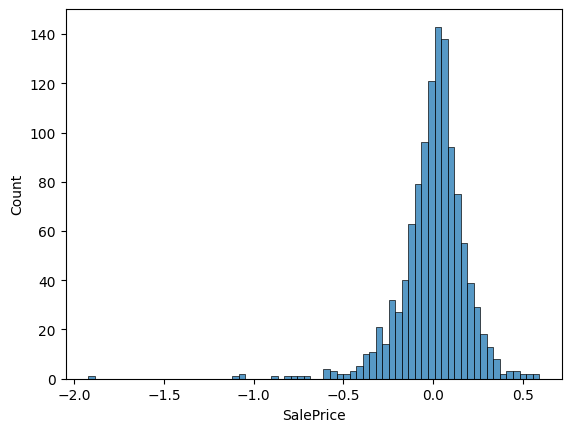

In [280]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)

residual = y - pred
sns.histplot(residual)

In [281]:
X, X_test, y = preprocess(train, test)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

oof_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=5,
    n_jobs=-1
)

residual = y - oof_pred
z = (residual - residual.mean()) / residual.std()

outliers = np.abs(z) > 3

train = train.loc[~outliers].copy()

print("removed:", outliers.sum())
print("ratio:", outliers.mean())

removed: 14
ratio: 0.011986301369863013


In [282]:
# 전처리
X, X_test, y = preprocess(train, test)

# 모델 평가
evaluate_model(model, X, y, cv)

RMSE: 0.1491 std: 0.0074
R²:   0.8476 std: 0.0140


- 이상치 제거로 RMSE가 0.1849 -> .1491로 감소하고 편차도 감소했다.

## 피처 엔지니어링
- 편포한 피처들을 로그변환하여 정규분포화
- 피처들을 함축해서 표현할만한 새로운 피처를 추가

In [283]:
skew_cols = ['LotArea','TotalBsmtSF']

for col in skew_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

# 전체 면적
train['TotalSF'] = (train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF'])
test['TotalSF'] = (test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF'])

# 화장실 개수
train['TotalBath'] = (train['FullBath'] + 0.5 * train['HalfBath'] + train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath'])
test['TotalBath'] = (test['FullBath'] + 0.5 * test['HalfBath'] + test['BsmtFullBath'] + 0.5 * test['BsmtHalfBath'])

In [284]:
X, X_test, y = preprocess(train, test)
evaluate_model(model, X, y, cv)

RMSE: 0.1492 std: 0.0072
R²:   0.8476 std: 0.0138


- RMSE가 근소하게 증가

## 모델 비교
- 베이스라인 모델(엘라스틱넷)과 다른 모델을 비교하여 더 나은 모델을 선택

In [285]:
def compare_models(X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        'ElasticNet': ElasticNet(alpha=0.05, l1_ratio=0.7, max_iter=10000, random_state=42),
        'Ridge': Ridge(alpha=10, random_state=42),
        'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42),
        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    }

    results = []

    for name, model in models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

        rmse = -scores['test_score']

        results.append({
            'Model': name,
            'RMSE_mean': rmse.mean(),
            'RMSE_std': rmse.std()
        })

    return pd.DataFrame(results).sort_values('RMSE_mean')

In [286]:
results = compare_models(X, y)
print(results)

          Model  RMSE_mean  RMSE_std
2         Lasso   0.102987  0.002727
1         Ridge   0.108636  0.002897
3  RandomForest   0.128038  0.006241
0    ElasticNet   0.133955  0.006998


- 모델 비교 결과 Lasso 모델의 성능이 가장 좋았음

### Lasso 모델 하이퍼파라미터 튜닝

In [287]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(
        alphas=np.logspace(-5, -1, 400),
        cv=5,
        max_iter=20000,
        n_jobs=-1
    ))
])

pipe.fit(X, y)

alpha_tuned = pipe.named_steps['lasso'].alpha_

print("best alpha:", alpha_tuned)

best alpha: 0.0036007334849856203


In [288]:
model = Lasso(alpha=alpha_tuned, max_iter=10000, random_state=42)
evaluate_model(model, X, y, cv)

RMSE: 0.1001 std: 0.0050
R²:   0.9313 std: 0.0058


In [289]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X, y)

pred_log = pipe.predict(X_test)
pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': pred
})

submission.to_csv('submission.csv', index=False)

### kaggle score : 19790.13014 

## 앙상블 모델

In [290]:
X, X_test, y = preprocess(train, test)

In [291]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=alpha_tuned, max_iter=20000, random_state=42))
])

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1, random_state=42))
])

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

# meta model
meta = ElasticNet(alpha=0.001,l1_ratio=0.1) # 0.09746034031109027

stack = StackingRegressor(estimators=[('lasso', lasso), ('ridge', ridge), ('xgb', xgb)],
    final_estimator=meta,
    cv=5,
    passthrough=False,
    n_jobs=-1)

In [292]:
scores = cross_validate(stack,X,y,cv=cv,scoring='neg_root_mean_squared_error',n_jobs=-1)
rmse = -scores['test_score']

print(f'RMSE: {rmse.mean()}')
print(f'std:  {rmse.std()}')

RMSE: 0.09746034031109027
std:  0.0029751436906071695


In [78]:
# 중간 제출
stack.fit(X, y)

pred_log = stack.predict(X_test)

pred = np.expm1(pred_log)

pred = np.clip(pred, 0, None)

submission = pd.DataFrame({'Id': test_id,'SalePrice': pred})
submission.to_csv('submission_stack.csv', index=False)

### kaggle score : 19631.20631

## 앙상블 모델 하이퍼 파라미터 튜닝

- hyperopt를 통해 xgboost 튜닝

In [33]:
space = {
    'n_estimators': hp.quniform('n_estimators', 800, 3000, 200),
    'max_depth': hp.choice('max_depth', [3,4,5,6]),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.05)),
    'subsample': hp.uniform('subsample', 0.6, 0.95),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 0.95),
    'min_child_weight': hp.choice('min_child_weight', [1,3,5,7]),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-4), np.log(1)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.5), np.log(5)),
}

In [37]:
def objective(params):

    model = XGBRegressor(
        n_estimators=int(params['n_estimators']),
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        min_child_weight=params['min_child_weight'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        n_jobs=-1
    )

    rmse = -cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()

    return {
        'loss': rmse,
        'status': STATUS_OK
    }

In [38]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=40,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print(best)

  0%|                                    | 0/40 [00:00<?, ?trial/s, best loss=?]

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using thi

  2%|▏        | 1/40 [00:03<02:22,  3.64s/trial, best loss: 0.11485716715888328]

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


  5%|▍        | 2/40 [00:05<01:30,  2.39s/trial, best loss: 0.11281206808915789]

...

 10%|▉        | 4/40 [00:08<01:09,  1.94s/trial, best loss: 0.10135748729741953]

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


 12%|█▏       | 5/40 [00:10<01:04,  1.85s/trial, best loss: 0.10135748729741953]

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


100%|████████| 40/40 [01:05<00:00,  1.63s/trial, best loss: 0.10112890540498916]
{'colsample_bytree': np.float64(0.6820862683773513), 'learning_rate': np.float64(0.007113575594927007), 'max_depth': np.int64(0), 'min_child_weight': np.int64(3), 'n_estimators': np.float64(3000.0), 'reg_alpha': np.float64(0.0025277444941355785), 'reg_lambda': np.float64(0.6339457146958903), 'subsample': np.float64(0.7137321609770884)}


In [39]:
best['max_depth'] = [3,4,5,6][best['max_depth']]
best['min_child_weight'] = [1,3,5,7][best['min_child_weight']]
best['n_estimators'] = int(best['n_estimators'])

- ridge 튜닝

In [42]:
alphas = np.logspace(-3, 3, 200)

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])

ridge_pipe.fit(X, y)

best_alpha = ridge_pipe.named_steps['ridge'].alpha_

print("Best Ridge alpha:", best_alpha)

Best Ridge alpha: 143.14589375234786


In [44]:
best_xgb_params = {
    'colsample_bytree': float(best['colsample_bytree']),
    'learning_rate': float(best['learning_rate']),
    'max_depth': int(best['max_depth']),
    'min_child_weight': float(best['min_child_weight']),
    'n_estimators': int(best['n_estimators']),
    'reg_alpha': float(best['reg_alpha']),
    'reg_lambda': float(best['reg_lambda']),
    'subsample': float(best['subsample']),
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1
}

In [48]:
# base model (tuned)
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=alpha_tuned, max_iter=20000, random_state=42))
])

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=float(best_alpha), random_state=42))
])

xgb = XGBRegressor(**best_xgb_params)


# Meta model tuning (ElasticNetCV)
meta_alphas = np.logspace(-4, 2, 400)
meta_l1s = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

meta_cv = ElasticNetCV(
    alphas=meta_alphas,
    l1_ratio=meta_l1s,
    cv=5,
    max_iter=50000,
    n_jobs=-1,
    random_state=42
)

meta_cv.fit(X_meta, y)

meta_alpha = float(meta_cv.alpha_)
meta_l1 = float(meta_cv.l1_ratio_)

print('Best meta ElasticNet alpha:', meta_alpha)
print('Best meta ElasticNet l1_ratio:', meta_l1)

meta_cv_scores = cross_validate(
    ElasticNet(
        alpha=meta_alpha,
        l1_ratio=meta_l1,
        max_iter=50000,
        random_state=42
    ),
    X_meta,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse = -meta_cv_scores['test_score']
print(f'Stacking CV RMSE: {rmse.mean():.6f}  std: {rmse.std():.6f}')

Best meta ElasticNet alpha: 0.0003359818286283781
Best meta ElasticNet l1_ratio: 0.1
Stacking CV RMSE: 0.096889  std: 0.003330


In [49]:
meta_final = ElasticNet(
    alpha=meta_alpha,
    l1_ratio=meta_l1,
    max_iter=50000,
    random_state=42
)

meta_final.fit(X_meta, y)

pred_log = meta_final.predict(X_test_meta)

pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': pred
})
submission.to_csv('submission_stack_enet_lasso_ridge_xgb.csv', index=False)
print('saved: submission_stack_enet_lasso_ridge_xgb.csv')

saved: submission_stack_enet_lasso_ridge_xgb.csv


### kaggle score : 19778.91671

---

In [79]:
def cv_rmse(model, X, y):
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    rmse = -scores['test_score']
    return rmse.mean(), rmse.std()

In [80]:
# 메타모델 튜닝
meta_alpha_grid = [3e-4, 1e-3, 3e-3, 1e-2]
meta_l1_grid = [0.0, 0.05, 0.1, 0.2, 0.3]

rows = []

for a in meta_alpha_grid:
    for l1 in meta_l1_grid:
        meta_tmp = ElasticNet(alpha=a, l1_ratio=l1, max_iter=50000, random_state=42)

        stack_tmp = StackingRegressor(
            estimators=[('lasso', lasso), ('ridge', ridge), ('xgb', xgb)],
            final_estimator=meta_tmp,
            cv=5,
            passthrough=False,
            n_jobs=-1
        )

        mean_rmse, std_rmse = cv_rmse(stack_tmp, X, y)
        rows.append([a, l1, mean_rmse, std_rmse])

res_meta = pd.DataFrame(rows, columns=['meta_alpha','meta_l1_ratio','rmse_mean','rmse_std'])\
            .sort_values('rmse_mean')

print(res_meta.head(10))

best_meta_alpha = float(res_meta.iloc[0]['meta_alpha'])
best_meta_l1 = float(res_meta.iloc[0]['meta_l1_ratio'])

print('>>> best meta:', best_meta_alpha, best_meta_l1)

meta_best = ElasticNet(alpha=best_meta_alpha, l1_ratio=best_meta_l1, max_iter=50000, random_state=42)

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.708e+00, tolerance: 1.372e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.484e+00, tolerance: 1.367e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

    meta_alpha  meta_l1_ratio  rmse_mean  rmse_std
5        0.001           0.00   0.097458  0.002954
6        0.001           0.05   0.097460  0.002964
7        0.001           0.10   0.097460  0.002975
8        0.001           0.20   0.097463  0.002999
9        0.001           0.30   0.097468  0.003025
13       0.003           0.20   0.097518  0.002905
12       0.003           0.10   0.097518  0.002877
11       0.003           0.05   0.097520  0.002863
14       0.003           0.30   0.097521  0.002936
10       0.003           0.00   0.097522  0.002852
>>> best meta: 0.001 0.0


In [81]:
# 릿지 모델 튜닝
ridge_alpha_grid = [0.3, 1, 3, 10, 30, 100, 300]

rows = []

for a in ridge_alpha_grid:
    ridge_tmp = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a, random_state=42))
    ])

    stack_tmp = StackingRegressor(
        estimators=[('lasso', lasso), ('ridge', ridge_tmp), ('xgb', xgb)],
        final_estimator=meta_best,
        cv=5,
        passthrough=False,
        n_jobs=-1
    )

    mean_rmse, std_rmse = cv_rmse(stack_tmp, X, y)
    rows.append([a, mean_rmse, std_rmse])

res_ridge = pd.DataFrame(rows, columns=['ridge_alpha','rmse_mean','rmse_std'])\
             .sort_values('rmse_mean')

print(res_ridge)

best_ridge_alpha = float(res_ridge.iloc[0]['ridge_alpha'])
print('>>> best ridge alpha:', best_ridge_alpha)

ridge_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=best_ridge_alpha, random_state=42))
])

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.624e+00, tolerance: 1.367e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.626e+00, tolerance: 1.354e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

   ridge_alpha  rmse_mean  rmse_std
6        300.0   0.097339  0.003258
5        100.0   0.097383  0.002886
4         30.0   0.097414  0.002778
3         10.0   0.097422  0.002828
2          3.0   0.097441  0.002906
1          1.0   0.097458  0.002954
0          0.3   0.097468  0.002980
>>> best ridge alpha: 300.0


/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.608e+00, tolerance: 1.367e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.421e+00, tolerance: 1.363e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

In [83]:
# xgboost 튜닝
depth_grid = [3, 4]
min_child_weight_grid = [1, 3, 5, 10]
reg_alpha_grid = [0.0, 0.05, 0.1, 0.3]
reg_lambda_grid = [1, 2, 5]

rows = []

for d in depth_grid:
    for mcw in min_child_weight_grid:
        for ra in reg_alpha_grid:
            for rl in reg_lambda_grid:
                xgb_tmp = XGBRegressor(
                    n_estimators=2000,
                    learning_rate=0.01,
                    max_depth=d,
                    min_child_weight=mcw,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=ra,
                    reg_lambda=rl,
                    random_state=42,
                    n_jobs=-1
                )

                stack_tmp = StackingRegressor(
                    estimators=[('lasso', lasso), ('ridge', ridge_best), ('xgb', xgb_tmp)],
                    final_estimator=meta_best,
                    cv=5,
                    passthrough=False,
                    n_jobs=-1
                )

                mean_rmse, std_rmse = cv_rmse(stack_tmp, X, y)
                rows.append([d, mcw, ra, rl, mean_rmse, std_rmse])

res_xgb = pd.DataFrame(rows, columns=[
    'max_depth','min_child_weight','reg_alpha','reg_lambda','rmse_mean','rmse_std'
]).sort_values('rmse_mean')

print(res_xgb.head(15))

best_row = res_xgb.iloc[0]
print('>>> best xgb:', best_row.to_dict())

xgb_best = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=int(best_row['max_depth']),
    min_child_weight=float(best_row['min_child_weight']),
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=float(best_row['reg_alpha']),
    reg_lambda=float(best_row['reg_lambda']),
    random_state=42,
    n_jobs=-1
)

/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.392e+00, tolerance: 1.363e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/jkyu/miniforge3/envs/dsbc/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.709e+00, tolerance: 1.350e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

KeyboardInterrupt: 

In [ ]:
stack_best = StackingRegressor(
    estimators=[('lasso', lasso), ('ridge', ridge_best), ('xgb', xgb_best)],
    final_estimator=meta_best,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

mean_rmse, std_rmse = cv_rmse(stack_best, X, y)
print(f'FINAL stacking RMSE: {mean_rmse:.6f}  std: {std_rmse:.6f}')

In [ ]:
stack_best.fit(X, y)
pred_log = stack_best.predict(X_test)

pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

submission = pd.DataFrame({'Id': test_id, 'SalePrice': pred})
submission.to_csv('submission_stack_tuned_seq.csv', index=False)
print('saved: submission_stack_tuned_seq.csv')